In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

# loading dataset
df = pd.read_csv("credit_card.csv")
print(f"Setup complete total {df.shape[0]} customer accounts are loaded.")

Setup complete total 8950 customer accounts are loaded.


In [2]:
# copy created to avoid slicwe warnings
df_clean = df.drop_duplicates().copy()

# missing values filled using column median
df_clean['CREDIT_LIMIT'] = df_clean['CREDIT_LIMIT'].fillna(df_clean['CREDIT_LIMIT'].median())
df_clean['MINIMUM_PAYMENTS'] = df_clean['MINIMUM_PAYMENTS'].fillna(0)

# all purchases are positive nos.
if 'PURCHASES' in df_clean.columns:
    df_clean['PURCHASES'] = df_clean['PURCHASES'].abs()

# risk flag definition
df_clean['Risk_Flag'] = 0
high_risk_condition = (df_clean['BALANCE'] > (df_clean['CREDIT_LIMIT'] * 0.8)) & (df_clean['PAYMENTS'] < 200)
df_clean.loc[high_risk_condition, 'Risk_Flag'] = 1

print("Data cleaning and risk definition complete.")
print(df_clean['Risk_Flag'].value_counts())

Data cleaning and risk definition complete.
Risk_Flag
0    8858
1      92
Name: count, dtype: int64


In [3]:
# features that dont lead to data leakage
features = ['INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'MINIMUM_PAYMENTS']

X = df_clean[features]
y = df_clean['Risk_Flag']

# 80% data for training and rest for tezting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# risk probability calculations
df_clean['Risk_Probability'] = model.predict_proba(X)[:, 1]
print("Machine learning pipeline successfull.")

Machine learning pipeline successfull.


In [4]:
# initialise optimization 
df_clean['Optimized_Limit'] = df_clean['CREDIT_LIMIT']
df_clean['Strategy_Action'] = 'Maintain Limit'

# rules applied
increase_rule = (df_clean['Risk_Probability'] < 0.15) & (df_clean['PURCHASES'] > 1000)
df_clean.loc[increase_rule, 'Optimized_Limit'] = df_clean['CREDIT_LIMIT'] * 1.30
df_clean.loc[increase_rule, 'Strategy_Action'] = 'Increase Limit (+30%)'

decrease_rule = (df_clean['Risk_Probability'] > 0.50)
df_clean.loc[decrease_rule, 'Optimized_Limit'] = df_clean['CREDIT_LIMIT'] * 0.50
df_clean.loc[decrease_rule, 'Strategy_Action'] = 'Decrease Limit (-50%)'

# financial impact calculations
capital_saved = (df_clean.loc[df_clean['Strategy_Action'].str.contains('Decrease'), 'CREDIT_LIMIT'] - 
                 df_clean.loc[df_clean['Strategy_Action'].str.contains('Decrease'), 'Optimized_Limit']).sum()

limit_expansion = (df_clean.loc[df_clean['Strategy_Action'].str.contains('Increase'), 'Optimized_Limit'] - 
                   df_clean.loc[df_clean['Strategy_Action'].str.contains('Increase'), 'CREDIT_LIMIT']).sum()
new_swipe_revenue = (limit_expansion * 0.15) * 0.02

print("Financial Impact Report")
print(f"\nTotal Risk Capital Insulated:                  ${capital_saved:,.2f}")
print(f"Projected New Annual Swipe Revenue Unlocked:    ${new_swipe_revenue:,.2f}")
print(f"Total Quantified Portfolio Value Generated:   ${(capital_saved + new_swipe_revenue):,.2f}")
print("\nActions")
print(df_clean['Strategy_Action'].value_counts())

# export results to csv file
df_clean.to_csv("credit_card_optimized_results.csv", index=False)
print("\nDataset successfully exported!")

Financial Impact Report

Total Risk Capital Insulated:                  $78,175.00
Projected New Annual Swipe Revenue Unlocked:    $13,661.05
Total Quantified Portfolio Value Generated:   $91,836.05

Actions
Strategy_Action
Maintain Limit           6426
Increase Limit (+30%)    2445
Decrease Limit (-50%)      79
Name: count, dtype: int64

Dataset successfully exported!


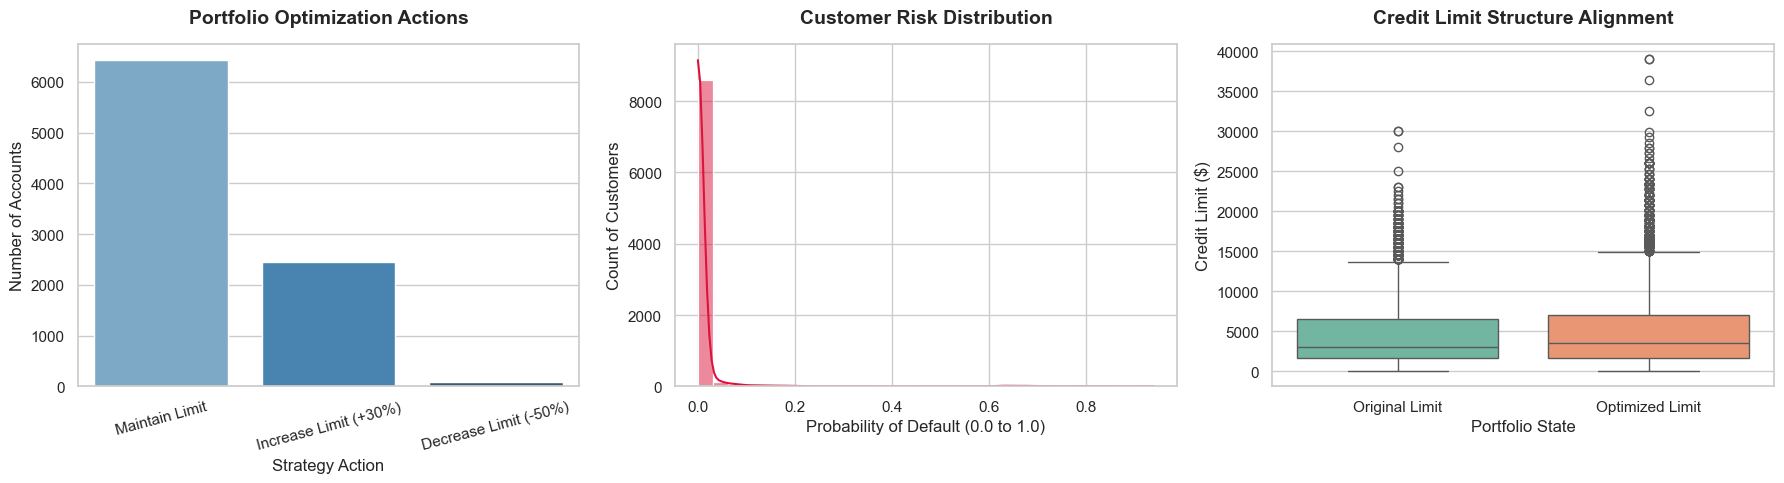

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 5))

# chart-1(bar)
plt.subplot(1, 3, 1)
strategy_counts = df_clean['Strategy_Action'].value_counts()

sns.barplot(
    x=strategy_counts.index, 
    y=strategy_counts.values, 
    hue=strategy_counts.index, 
    palette="Blues_d", 
    legend=False
)
plt.title("Portfolio Optimization Actions", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Strategy Action", fontsize=12)
plt.ylabel("Number of Accounts", fontsize=12)
plt.xticks(rotation=15)

# chart-2(histogram)
plt.subplot(1, 3, 2)
sns.histplot(data=df_clean, x='Risk_Probability', bins=30, kde=True, color="crimson")
plt.title("Customer Risk Distribution", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Probability of Default (0.0 to 1.0)", fontsize=12)
plt.ylabel("Count of Customers", fontsize=12)

# chart-3(box)
plt.subplot(1, 3, 3)
limit_comparison = df_clean[['CREDIT_LIMIT', 'Optimized_Limit']].melt(var_name='Timeline', value_name='Limit_Amount')
limit_comparison['Timeline'] = limit_comparison['Timeline'].replace({'CREDIT_LIMIT': 'Original Limit', 'Optimized_Limit': 'Optimized Limit'})

sns.boxplot(
    data=limit_comparison, 
    x='Timeline', 
    y='Limit_Amount', 
    hue='Timeline', 
    palette="Set2", 
    legend=False
)
plt.title("Credit Limit Structure Alignment", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Portfolio State", fontsize=12)
plt.ylabel("Credit Limit ($)", fontsize=12)

plt.tight_layout()
plt.show()

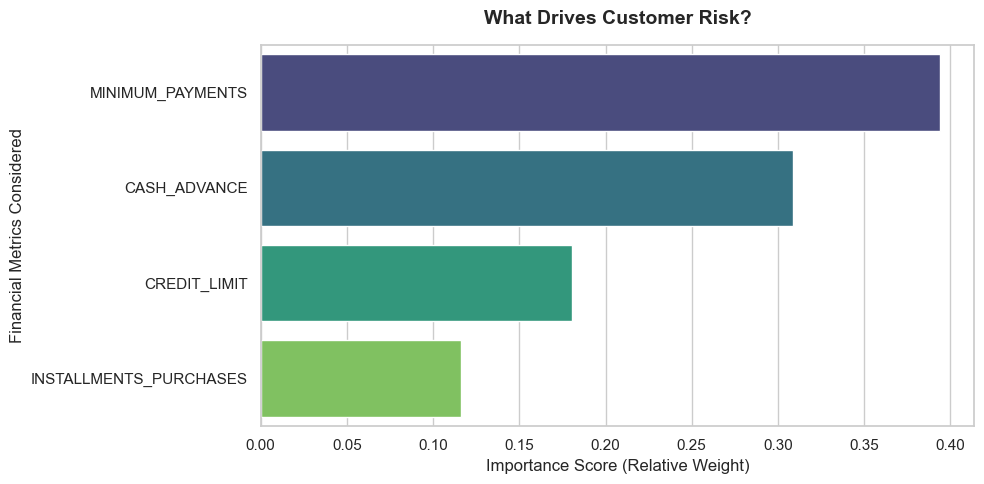

In [6]:
importances = model.feature_importances_

#clean panda series
feature_importance_df = pd.Series(importances, index=features).sort_values(ascending=False)

# horizontal bar chart
plt.figure(figsize=(10, 5))
sns.barplot(
    x=feature_importance_df.values, 
    y=feature_importance_df.index, 
    hue=feature_importance_df.index, 
    palette="viridis", 
    legend=False
)

plt.title("What Drives Customer Risk?", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Importance Score (Relative Weight)", fontsize=12)
plt.ylabel("Financial Metrics Considered", fontsize=12)
plt.tight_layout()
plt.show()

In [7]:
import sqlite3

# connect and create memory for SQl database
conn = sqlite3.connect(':memory:')
cursor = conn.cursor()

# table creation
cursor.execute('''
CREATE TABLE credit_portfolio (
    cust_id TEXT PRIMARY KEY,
    balance REAL,
    purchases REAL,
    credit_limit REAL,
    risk_flag INTEGER,
    risk_probability REAL,
    optimized_limit REAL,
    strategy_action TEXT
)
''')

# python dataframe into SQL
df_clean[['CUST_ID', 'BALANCE', 'PURCHASES', 'CREDIT_LIMIT', 'Risk_Flag', 'Risk_Probability', 'Optimized_Limit', 'Strategy_Action']].to_sql('credit_portfolio', conn, if_exists='append', index=False)

# audit query using SQL
audit_query = '''
SELECT 
    strategy_action AS portfolio_strategy,
    COUNT(cust_id) AS total_accounts,
    ROUND(AVG(risk_probability) * 100, 2) AS avg_risk_percentage,
    SUM(credit_limit) AS original_capital,
    SUM(optimized_limit) AS optimized_capital
FROM 
    credit_portfolio
GROUP BY 
    strategy_action;
'''

# display
sql_result = pd.read_sql_query(audit_query, conn)
sql_result

,portfolio_strategy,total_accounts,avg_risk_percentage,original_capital,optimized_capital
0,Decrease Limit (-50%),79,70.59,1.563500e+05,7.817500e+04
1,Increase Limit (+30%),2445,0.16,1.517894e+07,1.973263e+07
2,Maintain Limit,6426,0.51,2.488854e+07,2.488854e+07
